In [77]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

In [78]:
tiff_folder = "/Volumes/Windows8_OS/Dataset/Mask_oil/"   # Example (Mac)
png_folder  = "/Volumes/Windows8_OS/Dataset/Mask_Oil_PNG/" 

In [79]:
os.makedirs(png_folder, exist_ok=True)

# Convert .tif to .png

In [ ]:
## for root, dirs, files in os.walk(tiff_folder):
    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            tiff_path = os.path.join(root, file)
            
            # Construct equivalent PNG path
            relative_path = os.path.relpath(root, tiff_folder)
            output_dir = os.path.join(png_folder, relative_path)
            os.makedirs(output_dir, exist_ok=True)
            
            png_path = os.path.join(output_dir, os.path.splitext(file)[0] + ".png")

            # Open and convert
            with Image.open(tiff_path) as img:
                # Ensure image is saved as full-quality PNG (lossless)
                img.save(png_path, format="PNG", optimize=False, compress_level=0)
            
            print(f"Converted: {tiff_path}  →  {png_path}")

In [ ]:
print("\n✅ All TIFF images successfully converted to PNG without quality loss.")

# Visualize .tif images with 2 bands (R+G)

In [80]:
tif_path = "/Volumes/Windows8_OS/Dataset/Oil/00000.tif"

Bands: 2
Width: 2048 Height: 2048
CRS: EPSG:4326


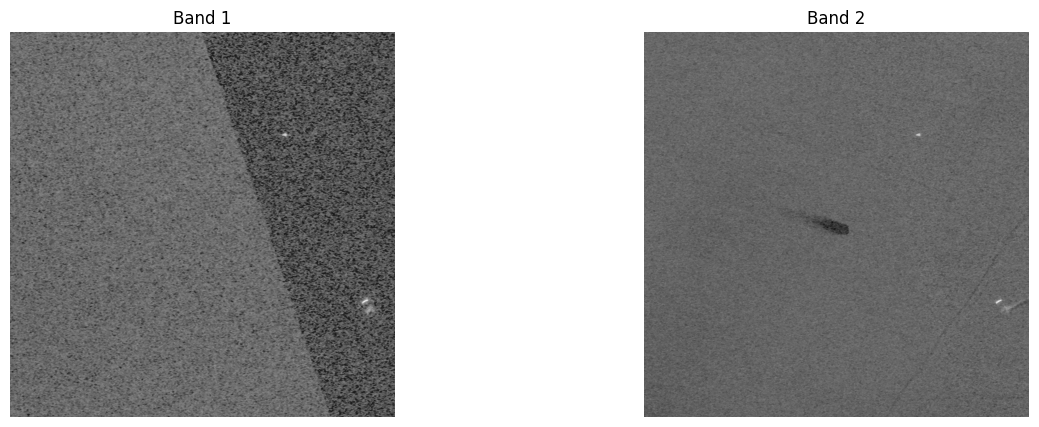

In [81]:
with rasterio.open(tif_path) as src:
    print("Bands:", src.count)
    print("Width:", src.width, "Height:", src.height)
    print("CRS:", src.crs)
    
    # Read all bands
    img = src.read()
    
    # Display each band separately
    fig, axes = plt.subplots(1, src.count, figsize=(15, 5))
    for i in range(src.count):
        axes[i].imshow(img[i], cmap='gray')
        axes[i].set_title(f'Band {i+1}')
        axes[i].axis('off')
    plt.show()

In [82]:
with rasterio.open(tif_path) as src:
    print("✅ File opened successfully!")
    print(f"Number of bands: {src.count}")
    print(f"Image size: {src.width} x {src.height}")
    print(f"Data type: {src.dtypes}")

✅ File opened successfully!
Number of bands: 2
Image size: 2048 x 2048
Data type: ('float32', 'float32')


# Combining 2 bands

In [83]:
with rasterio.open(tif_path) as src:
    if src.count < 2:
        raise ValueError("The TIFF file must have at least 2 bands (R and G).")
    R = src.read(1).astype(np.float32)
    G = src.read(2).astype(np.float32)

In [84]:
def scale_to_uint8(band, min_val=None, max_val=None):
    # Use percentiles to avoid extreme outliers
    if min_val is None or max_val is None:
        min_val, max_val = np.percentile(band, (2, 98))
    band_scaled = (band - min_val) / (max_val - min_val)  # scale to 0-1
    band_scaled = np.clip(band_scaled, 0, 1)              # ensure 0-1
    return (band_scaled * 255).astype(np.uint8)

In [85]:
R_disp = scale_to_uint8(R)
G_disp = scale_to_uint8(G)
B_disp = np.zeros_like(R_disp)

In [86]:
RG_image = np.dstack((R_disp, G_disp, B_disp))

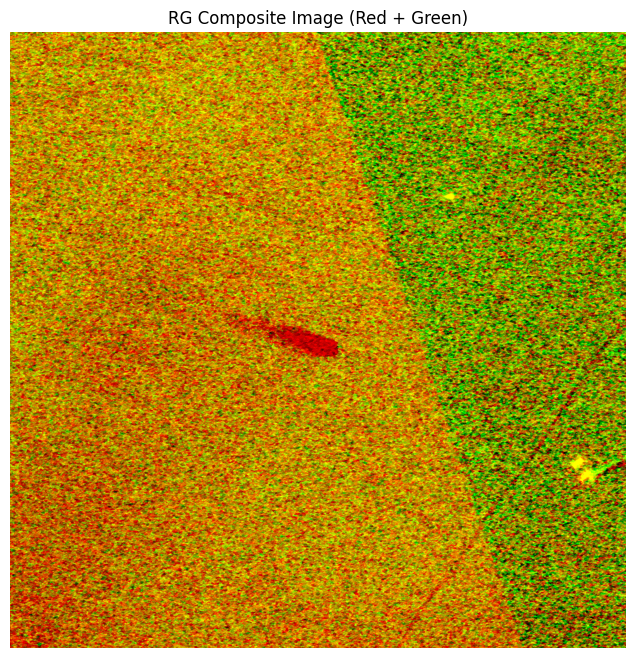

In [87]:
plt.figure(figsize=(8, 8))
plt.imshow(RG_image)
plt.axis('off')
plt.title("RG Composite Image (Red + Green)")
plt.show()

# Saving combined image

In [69]:
Image.fromarray(RG_image, mode="RGB").save("./img1.png")

/var/folders/9w/csn11pg56mz_mqtbmcxzdc340000gn/T/ipykernel_34121/307753207.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(RG_image, mode="RGB").save("./img1.png")


# Converting to greyscale

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [88]:
image = cv2.imread('./img.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [89]:
def show_image(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

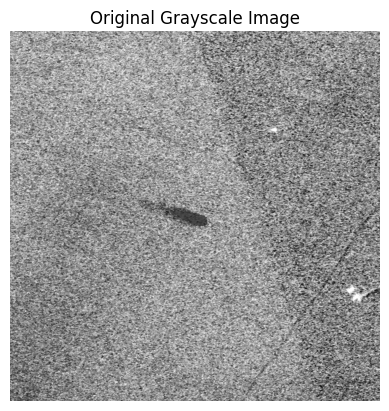

In [90]:
show_image(gray_image, "Original Grayscale Image")

# Applying Otsu

In [92]:
img = cv2.imread("./img.png", cv2.IMREAD_GRAYSCALE)

In [93]:
thresh_val, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [94]:
print(f"Otsu's threshold value: {thresh_val}")

Otsu's threshold value: 125.0


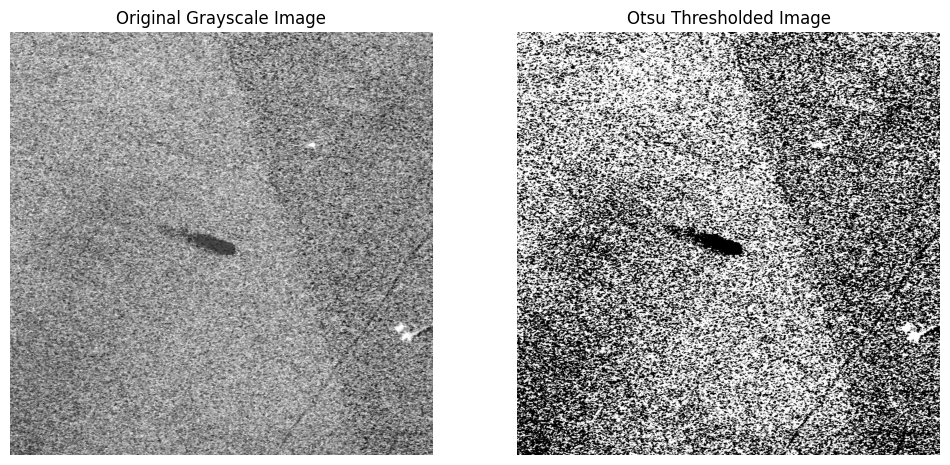

In [95]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_img, cmap='gray')
plt.title("Otsu Thresholded Image")
plt.axis('off')

plt.show()

# Dataset Conversion Script
Complete script to convert TIFF images from dataset-og folder structure to PNG and grayscale formats.

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import rasterio

In [ ]:
# Define folder paths
dataset_og_folder = "/path/to/your/dataset-og"  # Update this path
dataset_png_folder = "dataset-og-png"
dataset_gray_folder = "dataset-og-gray"

# Subfolders structure
main_folders = ["images", "masks"]
sub_folders = ["lookalike", "no oil", "oil"]

In [ ]:
# Create output directory structure
def create_directory_structure(base_path):
    """Create the required directory structure"""
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            folder_path = os.path.join(base_path, main_folder, sub_folder)
            os.makedirs(folder_path, exist_ok=True)
            print(f"Created directory: {folder_path}")

# Create PNG and grayscale directories
create_directory_structure(dataset_png_folder)
create_directory_structure(dataset_gray_folder)

In [ ]:
def scale_to_uint8(band, min_val=None, max_val=None):
    """Scale band values to 0-255 uint8 range"""
    if min_val is None or max_val is None:
        min_val, max_val = np.percentile(band, (2, 98))
    band_scaled = (band - min_val) / (max_val - min_val)
    band_scaled = np.clip(band_scaled, 0, 1)
    return (band_scaled * 255).astype(np.uint8)

def convert_tiff_to_png(input_folder, output_folder):
    """Convert all TIFF images (with R+G band combination) to PNG format"""
    total_converted = 0
    
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            input_path = os.path.join(input_folder, main_folder, sub_folder)
            output_path = os.path.join(output_folder, main_folder, sub_folder)
            
            if not os.path.exists(input_path):
                print(f"⚠️  Input path not found: {input_path}")
                continue
                
            # Get all TIFF files
            tiff_files = [f for f in os.listdir(input_path) 
                         if f.lower().endswith(('.tif', '.tiff'))]
            
            if not tiff_files:
                print(f"No TIFF files found in: {input_path}")
                continue
                
            print(f"\n📂 Processing {len(tiff_files)} files in {main_folder}/{sub_folder}")
            
            for file in tqdm(tiff_files, desc=f"Converting {main_folder}/{sub_folder}"):
                try:
                    tiff_path = os.path.join(input_path, file)
                    png_filename = os.path.splitext(file)[0] + ".png"
                    png_path = os.path.join(output_path, png_filename)
                    
                    # Use rasterio to handle multi-band TIFF files
                    import rasterio
                    with rasterio.open(tiff_path) as src:
                        if src.count >= 2:
                            # Read R and G bands
                            R = src.read(1).astype(np.float32)
                            G = src.read(2).astype(np.float32)
                            
                            # Scale bands to uint8
                            R_disp = scale_to_uint8(R)
                            G_disp = scale_to_uint8(G)
                            B_disp = np.zeros_like(R_disp)  # Blue channel set to zero
                            
                            # Combine into RGB image
                            RG_image = np.dstack((R_disp, G_disp, B_disp))
                            
                            # Save as PNG
                            Image.fromarray(RG_image, mode="RGB").save(png_path)
                            
                        else:
                            # Single band - convert directly
                            band = src.read(1).astype(np.float32)
                            band_scaled = scale_to_uint8(band)
                            Image.fromarray(band_scaled, mode="L").save(png_path)
                    
                    total_converted += 1
                    
                except Exception as e:
                    print(f"❌ Error converting {file}: {str(e)}")
    
    print(f"\n✅ Successfully converted {total_converted} TIFF images to PNG format!")
    return total_converted

In [ ]:
def convert_png_to_grayscale(input_folder, output_folder):
    """Convert all PNG images to grayscale"""
    total_converted = 0
    
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            input_path = os.path.join(input_folder, main_folder, sub_folder)
            output_path = os.path.join(output_folder, main_folder, sub_folder)
            
            if not os.path.exists(input_path):
                print(f"⚠️  Input path not found: {input_path}")
                continue
                
            # Get all PNG files
            png_files = [f for f in os.listdir(input_path) 
                        if f.lower().endswith('.png')]
            
            if not png_files:
                print(f"No PNG files found in: {input_path}")
                continue
                
            print(f"\n📂 Processing {len(png_files)} files in {main_folder}/{sub_folder}")
            
            for file in tqdm(png_files, desc=f"Converting {main_folder}/{sub_folder} to grayscale"):
                try:
                    png_path = os.path.join(input_path, file)
                    gray_path = os.path.join(output_path, file)
                    
                    # Read image using OpenCV
                    image = cv2.imread(png_path)
                    
                    if image is None:
                        print(f"❌ Could not read image: {file}")
                        continue
                    
                    # Convert to grayscale
                    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    
                    # Save grayscale image
                    cv2.imwrite(gray_path, gray_image)
                    
                    total_converted += 1
                    
                except Exception as e:
                    print(f"❌ Error converting {file} to grayscale: {str(e)}")
    
    print(f"\n✅ Successfully converted {total_converted} PNG images to grayscale!")
    return total_converted

In [ ]:
def display_sample_images(tiff_folder, png_folder, gray_folder):
    """Display sample PNG and grayscale images"""
    # Find a sample image from the first available subfolder
    sample_found = False
    
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            png_path = os.path.join(png_folder, main_folder, sub_folder)
            gray_path = os.path.join(gray_folder, main_folder, sub_folder)
            
            if os.path.exists(png_path):
                png_files = [f for f in os.listdir(png_path) 
                           if f.lower().endswith('.png')]
                if png_files:
                    sample_file = png_files[0]
                    sample_name = os.path.splitext(sample_file)[0]
                    
                    # Load images
                    try:
                        # PNG version
                        png_img = Image.open(os.path.join(png_path, sample_file))
                        
                        # Grayscale version
                        gray_img = cv2.imread(os.path.join(gray_path, sample_file), cv2.IMREAD_GRAYSCALE)
                        
                        # Display
                        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                        
                        axes[0].imshow(png_img)
                        axes[0].set_title(f'PNG (RG Composite)\n({main_folder}/{sub_folder})')
                        axes[0].axis('off')
                        
                        axes[1].imshow(gray_img, cmap='gray')
                        axes[1].set_title('Grayscale Conversion')
                        axes[1].axis('off')
                        
                        plt.tight_layout()
                        plt.show()
                        
                        sample_found = True
                        break
                        
                    except Exception as e:
                        print(f"Error displaying sample: {str(e)}")
                        continue
        
        if sample_found:
            break
    
    if not sample_found:
        print("No sample images found to display")

## Step 1: Convert TIFF to PNG
**Important**: Update the `dataset_og_folder` path above to point to your actual dataset-og folder location before running this cell.

In [ ]:
# Step 1: Convert TIFF images to PNG
print("🚀 Starting TIFF to PNG conversion...")
print(f"Input folder: {dataset_og_folder}")
print(f"Output folder: {dataset_png_folder}")

png_count = convert_tiff_to_png(dataset_og_folder, dataset_png_folder)

## Step 2: Convert PNG to Grayscale

In [ ]:
# Step 2: Convert PNG images to grayscale
print("🚀 Starting PNG to grayscale conversion...")
print(f"Input folder: {dataset_png_folder}")
print(f"Output folder: {dataset_gray_folder}")

gray_count = convert_png_to_grayscale(dataset_png_folder, dataset_gray_folder)

## Step 3: Display Sample Results

In [ ]:
# Display sample images to verify conversions
print("📸 Displaying sample images from conversion process...")
display_sample_images(dataset_og_folder, dataset_png_folder, dataset_gray_folder)

## Summary
The script above performs the following operations:

1. **TIFF to PNG Conversion**: Converts all TIFF images from your `dataset-og` folder to PNG format and saves them in `dataset-og-png` folder
2. **PNG to Grayscale Conversion**: Converts all PNG images to grayscale and saves them in `dataset-og-gray` folder

### Folder Structure:
```
dataset-og/
├── images/
│   ├── lookalike/ (TIFF files)
│   ├── no oil/ (TIFF files)
│   └── oil/ (TIFF files)
└── masks/
    ├── lookalike/ (TIFF files)
    ├── no oil/ (TIFF files)
    └── oil/ (TIFF files)

dataset-og-png/
├── images/
│   ├── lookalike/ (PNG files)
│   ├── no oil/ (PNG files)
│   └── oil/ (PNG files)
└── masks/
    ├── lookalike/ (PNG files)
    ├── no oil/ (PNG files)
    └── oil/ (PNG files)

dataset-og-gray/
├── images/
│   ├── lookalike/ (Grayscale PNG files)
│   ├── no oil/ (Grayscale PNG files)
│   └── oil/ (Grayscale PNG files)
└── masks/
    ├── lookalike/ (Grayscale PNG files)
    ├── no oil/ (Grayscale PNG files)
    └── oil/ (Grayscale PNG files)
```

**Note**: Remember to update the `dataset_og_folder` path to point to your actual dataset-og folder location before running the conversion.